# NEXUS


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##1.1 L'attention “jouet” en NumPy pour comprendre

In [ ]:
import numpy as np

n, d = 4, 8
X = np.random.randn(n, d)

scores = X @ X.T
A = np.exp(scores) / np.sum(np.exp(scores), axis=1, keepdims=True)
O = A @ X

print("Output shape:", O.shape)

Output shape: (4, 8)


## 1.2 L'attention sous forme de classe

In [ ]:
class SimpleAttention:

    def __init__(self):
        pass

    def forward(self, X):
        S = X @ X.T

        A = np.zeros((X.shape[0], X.shape[0]))
        for i in range(X.shape[0]):
            e = np.exp(S[i])
            A[i] = e / e.sum()

        O = A @ X

        return O, A

n = 10
d = 8
X = np.random.randn(n, d)

att = SimpleAttention()
O, A = att.forward(X)

print("X.shape:", X.shape)
print("O.shape:", O.shape)
print("Ligne 3 de A:", A[3])
print("Somme ligne 3:", A[3].sum())

X.shape: (10, 8)
O.shape: (10, 8)
Ligne 3 de A: [1.52143061e-07 1.08645358e-07 3.75643192e-08 9.99713585e-01
 1.52363410e-05 3.74292655e-07 7.87983575e-06 2.95357929e-07
 2.61768017e-04 5.62416995e-07]
Somme ligne 3: 1.0


### 1.3 Passage en couche Keras


In [ ]:
import tensorflow as tf
class SimpleAttention(tf.keras.layers.Layer):

    def __init__(self):
        super().__init__()
        self.S = None
        self.A = None
        self.O = None

    def call(self, X):
        self.S = X @ tf.transpose(X, perm=[0, 2, 1])

        A = tf.nn.softmax(self.S, axis=-1)
        self.A = A

        self.O = A @ X
        return self.O

    def get_S(self):
        return self.S

    def get_A(self):
        return self.A

    def get_O(self):
        return self.O

n = 10
d = 8
X = np.random.randn(1, n, d).astype(np.float32)

layer = SimpleAttention()
O = layer(X)

print("X.shape:", X.shape)
print("O.shape:", O.shape)
print("Ligne 3 de A:", layer.get_A()[0][3].numpy())
print("Somme ligne 3:", tf.reduce_sum(layer.get_A()[0][3]).numpy())

X.shape: (1, 10, 8)
O.shape: (1, 10, 8)
Ligne 3 de A: [2.1442673e-05 4.4945985e-08 3.5215093e-09 9.9978858e-01 7.6634359e-07
 1.8231834e-04 8.3078341e-08 2.3599011e-06 2.7073643e-06 1.6881770e-06]
Somme ligne 3: 1.0


## 2. Premier test avec des embeddings

In [ ]:
import numpy as np
import tensorflow as tf

vocab = {
    "medicament": 0, "docteur": 1, "hopital": 2, "le": 3, "est": 4,
    "prend": 5, "dort": 6, "mange": 7, "grand": 8, "petit": 9,
    "malade": 10, "fatigue": 11, "rapide": 12, "lent": 13, "clinique": 14,
    "infirmier": 15, "ordonnance": 16, "patient": 17, "urgence": 18, "et": 19
}

phrases = [
    [0, 3, 4, 8, 1, 5, 19, 3, 9, 2],
    [0, 6, 3, 14, 19, 3, 16, 4, 12, 9],
    [0, 7, 3, 17, 19, 3, 18, 4, 10, 8],
    [0, 5, 3, 15, 19, 3, 1, 4, 13, 9],
    [0, 4, 11, 19, 3, 2, 6, 3, 16, 8],
    [0, 3, 10, 19, 1, 4, 8, 3, 17, 9],
    [0, 19, 3, 18, 4, 11, 3, 15, 6, 2],
    [0, 5, 3, 16, 19, 1, 4, 13, 3, 14],
    [3, 1, 4, 8, 19, 3, 2, 5, 12, 9],
    [3, 18, 6, 3, 14, 19, 3, 16, 4, 10],
    [3, 17, 7, 3, 1, 19, 3, 2, 4, 13],
    [3, 2, 5, 3, 15, 19, 3, 18, 4, 11],
    [3, 1, 6, 3, 16, 19, 3, 17, 4, 12],
    [3, 15, 4, 8, 19, 3, 14, 5, 12, 9],
    [3, 17, 10, 3, 18, 19, 3, 1, 4, 13],
    [3, 2, 11, 3, 15, 19, 3, 16, 6, 8],
]

labels = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]

X_train = np.array(phrases)
y_train = np.array(labels)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Embedding(input_dim=20, output_dim=32),
    SimpleAttention(),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=500, verbose=0)
print("Entrainement termine !")

print("\n TEST ")
avec_medicament = np.array([[0, 3, 4, 10, 2, 5, 19, 3, 9, 1]])
sans_medicament = np.array([[3, 1, 6, 3, 16, 19, 3, 17, 4, 12]])

print("Avec medicament:", model.predict(avec_medicament, verbose=0)[0][0])
print("Sans medicament:", model.predict(sans_medicament, verbose=0)[0][0])

Entrainement termine !

 TEST 
Avec medicament: 0.9979792
Sans medicament: 0.0005058508


Au départ le modèle donnait 0.63 et 0.34, ce qui montrait qu'il n'avait rien appris On a augmentés la dimension des embeddings de 8 à 32, ajouter une couche cachée et augmenter le nombre de lectures à 500. Après ces modifications on obtient 0.9978 et 0.0004, le modèle reconnaît quasi parfaitement si le mot médicament est présent ou non dans la phrase

## 3. Préparation du corpus Alice

On commence avec Alice in Wonderland car c'est un texte court, libre de droits et facile à manipuler.  
Ce corpus sert surtout de test pour vérifier que toute la chaîne fonctionne avant de passer à des données plus grandes.




In [ ]:
import urllib.request
import numpy as np
import re
import collections
import matplotlib.pyplot as plt

url = "https://www.gutenberg.org/files/11/11-0.txt"
response = urllib.request.urlopen(url)
raw = response.read().decode('utf-8')

start = raw.find("START OF THE PROJECT GUTENBERG EBOOK")
end = raw.find("END OF THE PROJECT GUTENBERG EBOOK")
text = raw[start:end]
text = text[text.index('\n')+1:]

print("taille :", len(text), "caracteres")
print(text[:200])

taille : 144606 caracteres

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER II


### 3.1 Tokenisation

La tokenisation transforme le texte brut en une liste de mots.  
C'est la première étape pour pouvoir donner le texte au modèle.


In [ ]:
def tokenize(text):
    text = text.lower()
    return re.findall(r"[a-z']+", text)

tokens = tokenize(text)
print("nb tokens :", len(tokens))
print(tokens[:20])

counts = collections.Counter(tokens)
print("\nmots uniques :", len(counts))
for w, c in counts.most_common(10):
    print(f"  {w} : {c}")

nb tokens : 27427
['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole']

mots uniques : 2575
  the : 1651
  and : 874
  to : 729
  a : 637
  it : 595
  she : 553
  i : 546
  of : 515
  said : 462
  you : 411


### 3.2 Vocabulaire

Le vocabulaire associe chaque mot à un identifiant numérique.  
Les mots trop rares sont ignorés afin de limiter la taille du modèle.


In [ ]:
w2i = {'<PAD>': 0, '<UNK>': 1}
idx = 2
for w, c in counts.most_common():
    if c >= 2:
        w2i[w] = idx
        idx += 1

i2w = {v: k for k, v in w2i.items()}
VOCAB_SIZE = len(w2i)

print("vocab :", VOCAB_SIZE)
print("alice ->", w2i.get('alice'))
print("rabbit ->", w2i.get('rabbit'))
print("queen ->", w2i.get('queen'))

vocab : 1471
alice -> 12
rabbit -> 90
queen -> 60


### 3.3 Création des séquences d'entraînement

Le modèle reçoit une fenêtre de 32 tokens et doit prédire le token suivant.  
C'est le même principe que les modèles de langage : apprendre à compléter une séquence.


In [ ]:

CTX = 32
encoded = [w2i.get(w, 1) for w in tokens]

X_lm = []
y_lm = []
for i in range(len(encoded) - CTX):
    X_lm.append(encoded[i:i+CTX])
    y_lm.append(encoded[i+CTX])

X_lm = np.array(X_lm)
y_lm = np.array(y_lm)

print("X_lm :", X_lm.shape)
print("y_lm :", y_lm.shape)

print("\nexemple :")
print(' '.join([i2w[i] for i in X_lm[100]]))
print("->", i2w[y_lm[100]])

X_lm : (27395, 32)
y_lm : (27395,)

exemple :
to get very tired of sitting by her sister on the bank and of having nothing to do once or twice she had peeped into the book her sister was reading but
-> it


## 4. Construction de NexusLM

Dans cette partie, on construit les principales briques du modèle : embeddings, attention multi-tête, masque causal et blocs Transformer.  
On reste proche des notions vues dans le cours afin de comprendre ce que fait le modèle à chaque étape.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization, Embedding

EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
CTX = 32

class PositionalEmbedding(Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings  = Embedding(vocab_size, embed_dim)
        self.position_embeddings = Embedding(sequence_length, embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        positions = tf.range(tf.shape(inputs)[-1])
        return self.token_embeddings(inputs) + self.position_embeddings(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length,
                        "vocab_size": self.vocab_size,
                        "embed_dim": self.embed_dim})
        return config

@tf.keras.utils.register_keras_serializable()
class MultiHeadAttentionLayer(Layer):
    def __init__(self, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.d_head    = embed_dim // num_heads
        self.embed_dim = embed_dim

        self.Wq = Dense(embed_dim, use_bias=False)
        self.Wk = Dense(embed_dim, use_bias=False)
        self.Wv = Dense(embed_dim, use_bias=False)
        self.Wo = Dense(embed_dim, use_bias=False)

    def causal_mask(self, batch_size, num_heads, seq_len):

        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        mask = tf.reshape(mask, (1, 1, seq_len, seq_len))
        return tf.tile(mask, [batch_size, num_heads, 1, 1])

    def split_heads(self, x, B):
        x = tf.reshape(x, (B, -1, self.num_heads, self.d_head))
        return tf.transpose(x, [0, 2, 1, 3])

    def call(self, x):
        B       = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]

        Q = self.split_heads(self.Wq(x), B)
        K = self.split_heads(self.Wk(x), B)
        V = self.split_heads(self.Wv(x), B)


        scores = tf.matmul(Q, K, transpose_b=True)
        scores = scores / tf.sqrt(tf.cast(self.d_head, tf.float32))

        mask = self.causal_mask(B, self.num_heads, seq_len)
        scores = scores * mask + (1.0 - mask) * -1e9

        self.A = tf.nn.softmax(scores, axis=-1)

        context = tf.matmul(self.A, V)
        context = tf.transpose(context, [0, 2, 1, 3])
        context = tf.reshape(context, (B, -1, self.embed_dim))
        return self.Wo(context)

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads})
        return config


@tf.keras.utils.register_keras_serializable()
class TransformerDecoderBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim    = embed_dim
        self.num_heads    = num_heads
        self.ff_dim       = ff_dim
        self.dropout_rate = dropout_rate

        self.att      = MultiHeadAttentionLayer(embed_dim, num_heads)
        self.ffn      = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.norm1    = LayerNormalization(epsilon=1e-6)
        self.norm2    = LayerNormalization(epsilon=1e-6)
        self.drop1    = Dropout(dropout_rate)
        self.drop2    = Dropout(dropout_rate)

    def call(self, x, training=False):

        attn_out = self.att(x)
        attn_out = self.drop1(attn_out, training=training)
        x = self.norm1(x + attn_out)


        ffn_out = self.ffn(x)
        ffn_out = self.drop2(ffn_out, training=training)
        return self.norm2(x + ffn_out)

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads,
                        "ff_dim": self.ff_dim, "dropout_rate": self.dropout_rate})
        return config


### 4.1 Assemblage du modèle

NexusLM prend une séquence de tokens en entrée et prédit le prochain token.  
Il correspond à la partie from scratch du projet.


In [ ]:
@tf.keras.utils.register_keras_serializable()
class NexusLM(tf.keras.Model):
    def __init__(self, sequence_length, vocab_size, embed_dim,
                 num_heads, ff_dim, num_layers, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocab_size      = vocab_size
        self.embed_dim       = embed_dim
        self.num_heads       = num_heads
        self.ff_dim          = ff_dim
        self.num_layers      = num_layers

        self.pos_embedding   = PositionalEmbedding(sequence_length, vocab_size, embed_dim)
        self.decoder_blocks  = [TransformerDecoderBlock(embed_dim, num_heads, ff_dim)
                                 for _ in range(num_layers)]
        self.layernorm       = LayerNormalization(epsilon=1e-6)
        self.dropout         = Dropout(0.1)
        self.output_layer    = Dense(vocab_size, activation="softmax")

    def call(self, inputs, training=False):
        x = self.pos_embedding(inputs)
        x._keras_mask = None
        for block in self.decoder_blocks:
            x = block(x, training=training)
        x = self.layernorm(x)
        x = self.dropout(x, training=training)
        return self.output_layer(x)

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length,
                        "vocab_size": self.vocab_size, "embed_dim": self.embed_dim,
                        "num_heads": self.num_heads, "ff_dim": self.ff_dim,
                        "num_layers": self.num_layers})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)



model = NexusLM(CTX, VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FF_DIM, NUM_LAYERS)

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "nexus_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ positional_embedding            │ ?                      │   0 (unbuilt) │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_block       │ ?                      │   0 (unbuilt) │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_block_1     │ ?                      │   0 (unbuilt) │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Entraînement sur Alice

On entraîne d'abord NexusLM sur Alice.  
Cette étape permet de vérifier que le modèle apprend bien, mais aussi d'observer les limites d'un petit corpus.


Epoch 1/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0716 - loss: 5.8562
Epoch 1: saving model to nexus_checkpoints/nexus_epoch01.keras

Epoch 1: finished saving model to nexus_checkpoints/nexus_epoch01.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.1010 - loss: 5.4366 - val_accuracy: 0.1314 - val_loss: 5.1468
Epoch 2/20
383/386 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1585 - loss: 4.5985
Epoch 2: saving model to nexus_checkpoints/nexus_epoch02.keras

Epoch 2: finished saving model to nexus_checkpoints/nexus_epoch02.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1593 - loss: 4.5706 - val_accuracy: 0.1307 - val_loss: 5.0731
Epoch 3/20
381/386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1982 - loss: 4.0548
Epoch 3: saving model to nexus_checkpoints/nexus_epoch03.keras

Epoch 3: finished saving model to nexus_checkpoints/nexus_epoch03.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1892 - loss: 4.1269 - val_accuracy: 0.1405

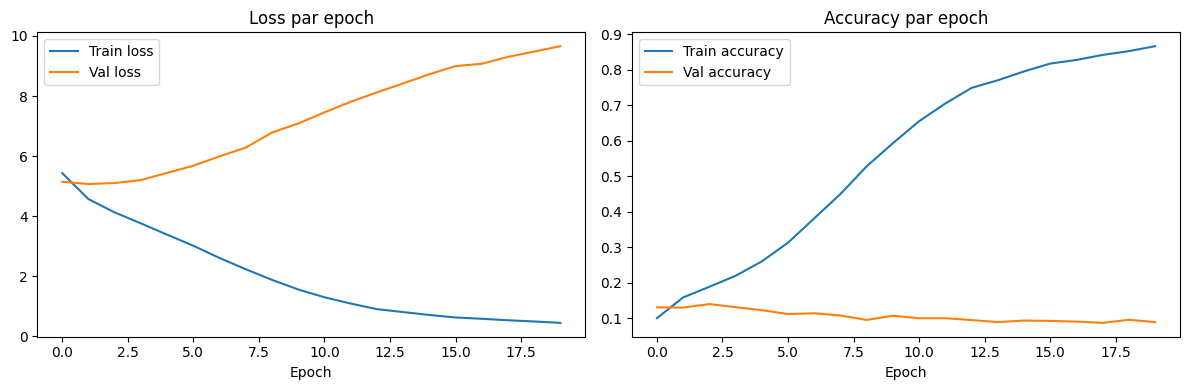

Courbes sauvegardées dans nexus.courbes.png


In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

EPOCHS=20
BATCH_SIZE=64
SAVE_DIR = "nexus_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

Checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR,"nexus_epoch{epoch:02d}.keras"),
    save_freq='epoch',
    save_best_only=False,
    verbose=1
)

input_layer = tf.keras.Input(shape=(CTX,), dtype=tf.int32, name='input_tokens')
x = model(input_layer)
x_last_token = x[:, -1, :]
corrected_model = tf.keras.Model(inputs=input_layer, outputs=x_last_token, name='Nexus_corrected')

corrected_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history=corrected_model.fit(
    X_lm,y_lm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[Checkpoint_cb],
    verbose=1
)


fig,(ax1,ax2)=plt.subplots(1, 2, figsize=(12,4))
ax1.plot(history.history['loss'], label='Train loss')
ax1.plot(history.history['val_loss'], label='Val loss')
ax1.set_title('Loss par epoch')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train accuracy')
ax2.plot(history.history['val_accuracy'], label='Val accuracy')
ax2.set_title('Accuracy par epoch')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('nexus.courbes.png', dpi=150)
plt.show()
print("Courbes sauvegardées dans nexus.courbes.png")

## 6. Génération de texte

Une fois entraîné, le modèle peut générer du texte mot par mot.  
La température permet de contrôler le niveau de hasard dans la génération.



In [ ]:
sequence_length = CTX
seed_text = "alice was beginning"

def generer(model, seed_text, w2i, i2w, sequence_length,
            num_words=40, temperature=0.8, top_k=10):

    mots = tokenize(seed_text)
    encoded = [w2i.get(mot, 1) for mot in mots]
    generated = encoded[:]

    for _ in range(num_words):
        seq = generated[-sequence_length:]
        seq = [0] * (sequence_length - len(seq)) + seq
        x = np.array([seq])

        pred = model.predict(x, verbose=0)

        if pred.ndim == 3:
            probs = pred[0, -1]
        else:
            probs = pred[0]

        probs = np.array(probs, dtype=np.float64)


        probs[0] = 0
        probs[1] = 0


        probs = np.log(probs + 1e-8) / temperature
        probs = np.exp(probs - np.max(probs))
        probs = probs / np.sum(probs)

        top_indices = np.argsort(probs)[-top_k:]
        top_probs = probs[top_indices]
        top_probs = top_probs / np.sum(top_probs)

        next_id = int(np.random.choice(top_indices, p=top_probs))
        generated.append(next_id)

    return " ".join(i2w.get(i, "<UNK>") for i in generated)


In [ ]:
print("Temperature = 0.8")
print(generer(corrected_model, "alice was beginning", w2i, i2w, CTX, temperature=0.8))

print("Temperature = 1.2")
print(generer(corrected_model, "alice was beginning", w2i, i2w, CTX, temperature=1.2))


Temperature = 0.8
alice was beginning of this and when and looked very much to speak and this question and was too much to speak what to herself he did so she said without waiting outside the game of the dish of course oh don t
Temperature = 1.2
alice was beginning was not much as pigs and with and went to herself and when she said the she was gone and this it was very good many little shriek and a hurried off besides was as if it makes them and


## 7. Passage au corpus PubMed

Après Alice, on garde la même architecture mais on change le corpus.  
PubMed contient des textes scientifiques biomédicaux. L'objectif est de voir si le modèle apprend un vocabulaire plus adapté au domaine de la santé.

On ne charge qu'une partie du dataset, car le corpus complet est trop volumineux pour Colab.


In [ ]:
checkpoint_dir = "/content/drive/My Drive/nexus_checkpoints/pubmed_big"

In [ ]:
!pip install -q datasets pypdf pandas openpyxl scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 13.9 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

import pandas as pd
from pypdf import PdfReader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
import textwrap
import math

### 7.1 Chargement du dataset PubMed


In [ ]:
from datasets import load_dataset
MAX_DOCS = 25000

ds_pubmed = load_dataset(
    "ccdv/pubmed-summarization",
    "document",
    split="train",
    streaming=True
)

textes_pubmed = []

for exemple in ds_pubmed:
    abstract = exemple["abstract"]

    if abstract is not None and len(abstract) > 300:
        abstract = abstract.replace("\n", " ")
        textes_pubmed.append(abstract)

    if len(textes_pubmed) >= MAX_DOCS:
        break

raw_pubmed = "\n".join(textes_pubmed)

print("nombre de documents :", len(textes_pubmed))
print("nombre de caracteres :", len(raw_pubmed))
print(raw_pubmed[:500])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

nombre de documents : 25000
nombre de caracteres : 30899496
background : the present study was carried out to assess the effects of community nutrition intervention based on advocacy approach on malnutrition status among school - aged children in shiraz , iran.materials and methods : this case - control nutritional intervention has been done between 2008 and 2009 on 2897 primary and secondary school boys and girls ( 7 - 13 years old ) based on advocacy approach in shiraz , iran .   the project provided nutritious snacks in public schools over a 2-year pe


### 7.2 Tokenisation de PubMed


In [ ]:
pubmed_tokens = tokenize(raw_pubmed)

print("nombre de tokens :", len(pubmed_tokens))
print(pubmed_tokens[:30])

pubmed_counts = collections.Counter(pubmed_tokens)

print("mots uniques :", len(pubmed_counts))
print("mots les plus fréquents :", pubmed_counts.most_common(10))

nombre de tokens : 4296671
['background', 'the', 'present', 'study', 'was', 'carried', 'out', 'to', 'assess', 'the', 'effects', 'of', 'community', 'nutrition', 'intervention', 'based', 'on', 'advocacy', 'approach', 'on', 'malnutrition', 'status', 'among', 'school', 'aged', 'children', 'in', 'shiraz', 'iran', 'materials']
mots uniques : 78162
mots les plus fréquents : [('the', 217309), ('of', 183525), ('and', 163460), ('in', 114411), ('to', 80588), ('a', 77084), ('with', 59089), ('was', 45289), ('for', 40784), ('were', 38771)]


### 7.3 Création du vocabulaire PubMed


Le vocabulaire PubMed est plus spécialisé que celui d'Alice.  
On s'attend à retrouver des mots comme patient, treatment, disease ou clinical.



In [ ]:
MIN_FREQ = 3
MAX_VOCAB = 30000

w2i_pubmed = {"<PAD>": 0, "<UNK>": 1}

for mot, freq in pubmed_counts.most_common():
    if freq < MIN_FREQ:
        continue

    if len(w2i_pubmed) >= MAX_VOCAB:
        break

    w2i_pubmed[mot] = len(w2i_pubmed)

i2w_pubmed = {i: w for w, i in w2i_pubmed.items()}

VOCAB_SIZE_PUBMED = len(w2i_pubmed)

print("taille vocabulaire PubMed :", VOCAB_SIZE_PUBMED)
print("id du mot patient :", w2i_pubmed.get("patient", "absent"))
print("id du mot treatment :", w2i_pubmed.get("treatment", "absent"))

taille vocabulaire PubMed : 30000
id du mot patient : 44
id du mot treatment : 32


### 7.4 Encodage  du corpus PubMed



In [ ]:
encoded_pubmed = []

for word in pubmed_tokens:
    if word in w2i_pubmed:
        encoded_pubmed.append(w2i_pubmed[word])
    else:
        encoded_pubmed.append(w2i_pubmed["<UNK>"])

print("nombre d'ids :", len(encoded_pubmed))
print("exemple :", encoded_pubmed[:30])

nombre d'ids : 4296671
exemple : [160, 2, 91, 24, 9, 768, 251, 6, 332, 2, 115, 3, 742, 2219, 334, 88, 18, 12229, 282, 18, 4909, 314, 99, 1294, 538, 150, 5, 7528, 896, 162]


### 7.5 Création des séquences PubMed

Comme pour Alice, on construit des couples entrée/sortie.  
L'entrée est une séquence de 32 tokens, et la sortie est le token suivant.


In [ ]:
MAX_SEQ = 2000000

X_pubmed = []
y_pubmed = []

limit = min(len(encoded_pubmed) - CTX, MAX_SEQ)

for i in range(limit):
    X_pubmed.append(encoded_pubmed[i:i+CTX])
    y_pubmed.append(encoded_pubmed[i+CTX])

X_pubmed = np.array(X_pubmed, dtype=np.int32)
y_pubmed = np.array(y_pubmed, dtype=np.int32)

print("Nombre total de tokens PubMed :", len(encoded_pubmed))
print("Nombre maximum de séquences possibles :", len(encoded_pubmed) - CTX)
print("Nombre de séquences utilisées :", len(X_pubmed))
print("Pourcentage utilisé :", round(100 * len(X_pubmed) / (len(encoded_pubmed) - CTX), 2), "%")

print("X_pubmed :", X_pubmed.shape)
print("y_pubmed :", y_pubmed.shape)

print("\nExemple entrée :")
print(" ".join(i2w_pubmed[id] for id in X_pubmed[0]))

print("\nMot à prédire :")
print(i2w_pubmed[y_pubmed[0]])


Nombre total de tokens PubMed : 4296671
Nombre maximum de séquences possibles : 4296639
Nombre de séquences utilisées : 2000000
Pourcentage utilisé : 46.55 %
X_pubmed : (2000000, 32)
y_pubmed : (2000000,)

Exemple entrée :
background the present study was carried out to assess the effects of community nutrition intervention based on advocacy approach on malnutrition status among school aged children in shiraz iran materials and methods

Mot à prédire :
this


### 7.6 Création du modèle PubMed


In [ ]:
base_pubmed = NexusLM(
    CTX,
    VOCAB_SIZE_PUBMED,
    EMBED_DIM,
    NUM_HEADS,
    FF_DIM,
    NUM_LAYERS
)

input_layer = tf.keras.Input(shape=(CTX,), dtype=tf.int32)
x = base_pubmed(input_layer)
x_last = x[:, -1, :]

model_pubmed = tf.keras.Model(input_layer, x_last, name="Nexus_PubMed")

model_pubmed.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_pubmed.summary()

Model: "Nexus_PubMed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ nexus_lm_1 (NexusLM)            │ (None, 32, 30000)      │     7,978,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 30000)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,978,288 (30.43 MB)

 Trainable params: 7,978,288 (30.43 MB)

 Non-trainable params: 0 (0.00 B)

### 7.7 Entraînement de NexusLM sur PubMed

On réutilise la même classe NexusLM.  
La différence vient uniquement des données et du vocabulaire.


In [ ]:
import tensorflow as tf
import os

checkpoint_dir = "/content/drive/My Drive/nexus_checkpoints/pubmed_big"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_pubmed_big = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "nexus_pubmed_big_epoch{epoch:02d}.keras"),
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

early_stop_big = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history_pubmed_big = model_pubmed.fit(
    X_pubmed,
    y_pubmed,
    epochs=8,
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint_pubmed_big, early_stop_big],
    verbose=1
)

Epoch 1/8
28124/28125 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1306 - loss: 6.6791
Epoch 1: saving model to /content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch01.keras

Epoch 1: finished saving model to /content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch01.keras
28125/28125 ━━━━━━━━━━━━━━━━━━━━ 988s 35ms/step - accuracy: 0.1597 - loss: 6.2501 - val_accuracy: 0.1931 - val_loss: 5.8056
Epoch 2/8
28125/28125 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2020 - loss: 5.5787
Epoch 2: saving model to /content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch02.keras

Epoch 2: finished saving model to /content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch02.keras
28125/28125 ━━━━━━━━━━━━━━━━━━━━ 978s 35ms/step - accuracy: 0.2048 - loss: 5.5421 - val_accuracy: 0.2080 - val_loss: 5.5862
Epoch 3/8
28124/28125 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2236 - loss: 5.2335
Epoch 3: saving model to /

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/My Drive"):
    for f in files:
        if "pubmed_big" in f or "nexus_pubmed_big" in f:
            print(os.path.join(root, f))


/content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch01.keras
/content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch02.keras
/content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch03.keras
/content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch04.keras
/content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch05.keras
/content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch06.keras


In [ ]:
from google.colab import files

files.download("/content/drive/My Drive/nexus_checkpoints/pubmed_big/nexus_pubmed_big_epoch03.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

shutil.make_archive(
    "/content/pubmed_big_checkpoints",
    "zip",
    "/content/drive/My Drive/nexus_checkpoints/pubmed_big"
)


'/content/pubmed_big_checkpoints.zip'

In [ ]:
from google.colab import files
files.download("/content/pubmed_big_checkpoints.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7.8 Courbes d’apprentissage

Les courbes permettent de comparer l'apprentissage sur le train et sur la validation.  
Si la loss d'entraînement baisse mais que la validation remonte, cela indique un sur-apprentissage.


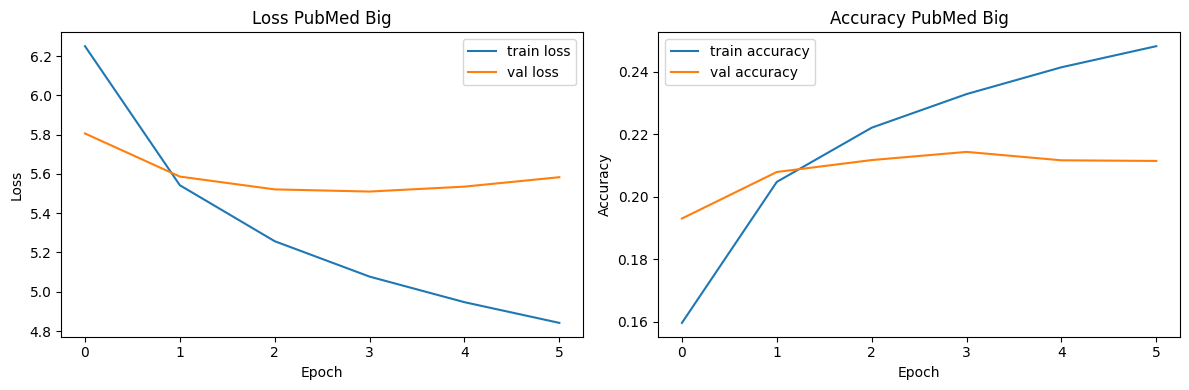

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_pubmed_big.history["loss"], label="train loss")
plt.plot(history_pubmed_big.history["val_loss"], label="val loss")
plt.title("Loss PubMed Big")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_pubmed_big.history["accuracy"], label="train accuracy")
plt.plot(history_pubmed_big.history["val_accuracy"], label="val accuracy")
plt.title("Accuracy PubMed Big")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("courbes_pubmed_big.png", dpi=150)
plt.show()



### 7.9 Génération avec le modèle PubMed

On teste quelques débuts de phrases médicales pour voir si le modèle produit un vocabulaire plus biomédical.



In [ ]:
print("Temperature = 0.8")
print(generer(model_pubmed, "the patient received", w2i_pubmed, i2w_pubmed, CTX, temperature=0.8))

print("Temperature = 1.0")
print(generer(model_pubmed, "the treatment", w2i_pubmed, i2w_pubmed, CTX, temperature=1.0))


Temperature = 0.8
the patient received a high cost of the treatment of this condition has been reported to be more pronounced with a high cost effectiveness in the use of the use of conservative treatment for the development of a year old boy visited the
Temperature = 1.0
the treatment options of the patients were given to this study aimed to investigate the impact of the treatment of type diabetes mellitus in the first time of the disease free period and the first decade of life of individuals with type


Bilan provisoire

À ce stade, NexusLM a été testé sur deux types de corpus : Alice et PubMed.  
Alice sert surtout à vérifier le fonctionnement du modèle, tandis que PubMed permet de rapprocher l'expérience de notre problématique biomédicale.

Les prochaines étapes sont :
- ajouter un module NER biomédical avec BiomedBERT pour extraire des entités      médicales ;
- ajouter un module RAG local pour interroger des documents PDF ou Excel ;
- comparer les résultats obtenus avec les différents corpus.


## 8. Extension NER / RAG / Ollama

L'extraction d'entités biomédicales, le RAG local et l'utilisation d'Ollama ne sont pas réalisés directement dans ce notebook d'entraînement PubMed.

Ce notebook est consacré à l'entraînement de NexusLM PubMed Big : préparation du corpus PubMed, création du vocabulaire, construction du modèle, entraînement, génération et sauvegarde.

Les extensions applicatives sont traitées dans un notebook séparé : `Nexus_Extensions_NER_RAG_BiomedBERT.ipynb`.

Cette séparation permet de distinguer clairement deux parties du projet :

- NexusLM PubMed Big : modèle génératif construit from scratch et entraîné sur PubMed.
- Extension NER/RAG/Ollama : extraction d'entités biomédicales, recherche de passages pertinents et génération locale d'une réponse à partir du contexte retrouvé.


In [ ]:
import pickle

with open("vocab_pubmed_big.pkl", "wb") as f:
    pickle.dump((w2i_pubmed, i2w_pubmed), f)

model_pubmed_big = model_pubmed
model_pubmed_big.save("model_pubmed_big.keras")

print("Vocabulaire PubMed Big sauvegardé : vocab_pubmed_big.pkl")
print("Modèle PubMed Big sauvegardé : model_pubmed_big.keras")


Vocabulaire PubMed Big sauvegardé : vocab_pubmed_big.pkl
Modèle PubMed Big sauvegardé : model_pubmed_big.keras


In [17]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/NEXUS/Rendu Devoir"
paths = [
    f"{BASE}/Interface.ipynb"
]

import os
for p in paths:
    print(("✓ " if os.path.exists(p) else "✗ ") + p)

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
rm: cannot remove '/content/drive/.Encrypted/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Encrypted/.shortcut-targets-by-id': Operation canceled
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✗ /content/drive/MyDrive/NEXUS/Rendu Devoir/Interface.ipynb


In [11]:
!ls /content/drive/MyDrive/ | grep -i nexus

ls: cannot access '/content/drive/MyDrive/': No such file or directory


In [12]:
!ls -la /content/drive/

ls: cannot access '/content/drive/': No such file or directory


In [14]:
!ls /content/drive/MyDrive/ | head -20

ls: cannot access '/content/drive/MyDrive/': No such file or directory


In [13]:
import time
time.sleep(5)
!ls /content/drive/
!ls /content/drive/MyDrive/ 2>&1 | head -20

ls: cannot access '/content/drive/': No such file or directory
ls: cannot access '/content/drive/MyDrive/': No such file or directory


In [10]:
import subprocess
subprocess.run(['pip','install','-q','nest_asyncio','playwright','nbconvert'], capture_output=True)
subprocess.run(['playwright','install','--with-deps','chromium'], capture_output=True)
subprocess.run(['apt-get','install','-y','fonts-lmodern','lmodern'], capture_output=True)
subprocess.run(['fc-cache','-fv'], capture_output=True)

import nest_asyncio; nest_asyncio.apply()
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)

# Mots-clés pour identifier la cellule de conversion à exclure
SKIP_MARKERS = ['colab_to_pdf', 'playwright', 'nest_asyncio',
                'fonts-lmodern', 'CSS = r"""']

def colab_to_pdf(notebook_path, output_name=None, no_input=False):
    import subprocess, shutil, json, asyncio, os, sys
    from pathlib import Path

    nb_path = Path(notebook_path)
    output_name = output_name or nb_path.stem
    final_dir = nb_path.parent

    work = Path("/tmp/nb_export"); work.mkdir(exist_ok=True)
    tmp_nb = work / nb_path.name
    shutil.copy(nb_path, tmp_nb)

    data = json.loads(tmp_nb.read_text(encoding='utf-8'))
    data.get('metadata', {}).pop('widgets', None)

    # Filtrage : on retire toute cellule qui contient le code de la fonction d'export
    kept_cells = []
    for cell in data.get('cells', []):
        src = ''.join(cell.get('source', []))
        if any(m in src for m in SKIP_MARKERS):
            continue
        for out in cell.get('outputs', []) or []:
            out.get('metadata', {}).pop('widgets', None)
        kept_cells.append(cell)
    data['cells'] = kept_cells
    tmp_nb.write_text(json.dumps(data), encoding='utf-8')

    html_file = work / f"{output_name}.html"
    pdf_file  = work / f"{output_name}.pdf"

    CSS = r"""
    @page { size: A4; margin: 22mm 20mm; }
    html, body { background: white !important; }

    body {
      font-family: 'Latin Modern Roman','CMU Serif',serif !important;
      font-size: 12pt; line-height: 1.55; color: #000;
      max-width: 100% !important;
    }

    h1, h2, h3, h4 {
      font-family: 'Latin Modern Sans','CMU Sans Serif',sans-serif !important;
      color: #000; font-weight: bold;
    }
    h1 { font-size: 22pt; margin-top: 0; }
    h2 { font-size: 16pt; margin-top: 1.4em; }
    h3 { font-size: 13pt; margin-top: 1.1em; }

    p { text-align: justify; hyphens: auto; margin: 0.5em 0; }

    /* IMPORTANT : on enleve TOUTE bordure/ombre sur les wrappers Jupyter */
    .jp-Cell, .jp-CodeCell, .jp-MarkdownCell,
    .jp-Cell-inputWrapper, .jp-Cell-outputWrapper,
    .jp-InputArea, .jp-InputArea-editor,
    .jp-OutputArea, .jp-OutputArea-output,
    .jp-RenderedHTMLCommon, .jp-Notebook {
      border: none !important;
      box-shadow: none !important;
      background: white !important;
      margin: 0 !important;
      padding: 0 !important;
    }

    /* UN SEUL cadre : sur le div.highlight (= le bloc Pygments du code) */
    div.highlight {
      border: 0.5pt solid #000 !important;
      background: white !important;
      padding: 0.7em 1em !important;
      margin: 0.8em 0 !important;
      border-radius: 0 !important;
      box-shadow: none !important;
    }
    div.highlight pre {
      border: none !important; background: transparent !important;
      padding: 0 !important; margin: 0 !important;
      box-shadow: none !important;
    }

    pre, code, .CodeMirror, .cm-editor {
      font-family: 'Latin Modern Mono','CMU Typewriter Text',monospace !important;
    }
    pre { font-size: 10pt; line-height: 1.4; white-space: pre-wrap; word-wrap: break-word; }
    code { font-size: 10.5pt; }

    /* Sorties : pas de cadre */
    .jp-OutputArea-output pre, .output_area pre, .jp-RenderedText pre {
      background: white !important; border: none !important;
      box-shadow: none !important; padding: 0.3em 0 !important;
    }

    .highlight .k, .highlight .kn, .highlight .kd, .highlight .kc { color: #007020; font-weight: bold; }
    .highlight .nf { color: #06287e; font-weight: bold; }
    .highlight .nb, .highlight .bp { color: #0e84b5; }
    .highlight .s, .highlight .s1, .highlight .s2, .highlight .sd, .highlight .sb { color: #c41a16; }
    .highlight .c, .highlight .c1, .highlight .cm, .highlight .cp { color: #408080; font-style: italic; }
    .highlight .mi, .highlight .mf, .highlight .mh, .highlight .il { color: #b30000; }
    .highlight .o, .highlight .ow, .highlight .n, .highlight .p { color: #000; }

    img { max-width: 92%; height: auto; display: block; margin: 0.8em auto; }

    table { border-collapse: collapse; margin: 1em auto; font-size: 10pt; }
    th, td { border: 0.5pt solid #888; padding: 4pt 8pt; }
    th { background: #eee; font-weight: bold; }

    .jp-InputArea-prompt, .jp-OutputArea-prompt,
    .input_prompt, .output_prompt, .prompt,
    .anchor-link { display: none !important; }

    a { color: #000; text-decoration: none; }
    """

    cmd = ['jupyter','nbconvert','--to','html','--embed-images',
           str(tmp_nb),'--output',output_name,'--log-level','ERROR']
    if no_input: cmd.append('--no-input')
    res = subprocess.run(cmd, cwd=str(work), capture_output=True, text=True)
    if res.returncode != 0:
        print(f"✗ {nb_path.name} — nbconvert a échoué")
        print(res.stderr[-800:])
        return None

    html = html_file.read_text(encoding='utf-8')
    html = html.replace('</head>', f'<style>{CSS}</style></head>')
    html_file.write_text(html, encoding='utf-8')

    from playwright.async_api import async_playwright
    async def render():
        async with async_playwright() as p:
            browser = await p.chromium.launch()
            page = await browser.new_page()
            await page.goto(f'file://{html_file.resolve()}', wait_until='networkidle')
            await page.emulate_media(media='print')
            await page.pdf(path=str(pdf_file), format='A4', print_background=True,
                           margin={'top':'22mm','bottom':'22mm','left':'20mm','right':'20mm'},
                           display_header_footer=False)
            await browser.close()

    devnull = open(os.devnull, 'w')
    old_stderr = sys.stderr; sys.stderr = devnull
    try:
        asyncio.get_event_loop().run_until_complete(render())
    finally:
        sys.stderr = old_stderr; devnull.close()

    final_pdf = final_dir / f"{output_name}.pdf"
    shutil.copy(pdf_file, final_pdf)
    html_file.unlink(missing_ok=True); pdf_file.unlink(missing_ok=True); tmp_nb.unlink()
    print(f"✓ {final_pdf.name}")
    return str(final_pdf)


BASE = "/content/drive/MyDrive/NEXUS/Rendu Devoir"
for nb in ["Interface.ipynb"]:
    try:
        colab_to_pdf(f"{BASE}/{nb}")
    except Exception as e:
        print(f"✗ {nb} — {e}")

✗ Interface.ipynb — [Errno 2] No such file or directory: '/content/drive/MyDrive/NEXUS/Rendu Devoir/Interface.ipynb'
